In [8]:
!pip install tensorflow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split


In [2]:
df= pd.read_csv('C:\\Users\\PMLS\\Documents\\All Uni Work\\Data Science & AI\\skin_disease_data\\hmnist_28_28_RGB.csv')
X= df.drop('label', axis=1).values
y= df['label'].values

df.shape

(10015, 2353)

In [3]:
X = X.reshape(-1, 28, 28, 3) / 255.0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:

X_train = X_train / 255.0
X_test = X_test / 255.0

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


In [20]:
from tensorflow.keras import regularizers

model = models.Sequential([
    #CNN layers
    layers.Conv2D(32, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_regularizer=regularizers.l2(0.0001), input_shape=(28,28,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),


    layers.Conv2D(128,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(256, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.5),


    #ANN layers --- flattening
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.BatchNormalization(),
    layers.Dense(128,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(7, activation='softmax')
])


In [21]:
#learning rate adjustment
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [22]:
model_prediction = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),epochs=40,validation_data=(X_test, y_test),callbacks=[early_stop, checkpoint, reduce_lr])

Epoch 1/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.3712 - loss: 1.9756 - val_accuracy: 0.0464 - val_loss: 2.8417 - learning_rate: 5.0000e-04
Epoch 2/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.6008 - loss: 1.2328 - val_accuracy: 0.1118 - val_loss: 3.2427 - learning_rate: 5.0000e-04
Epoch 3/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.6472 - loss: 1.0495 - val_accuracy: 0.2421 - val_loss: 2.1872 - learning_rate: 5.0000e-04
Epoch 4/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.6620 - loss: 0.9801 - val_accuracy: 0.6800 - val_loss: 0.9988 - learning_rate: 5.0000e-04
Epoch 5/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.6771 - loss: 0.9154 - val_accuracy: 0.6151 - val_loss: 1.0420 - learning_rate: 5.0000e-04
Epoch 6/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.6841 - loss: 0.8905 - val_accuracy: 0.6705 - val_loss: 1.3914 - learning_rate: 5.0000e-04
Epoch 7/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/ste

In [19]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

print("Final Training Accuracy:", model_prediction.history['accuracy'][-1])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7309 - loss: 0.7573
Test Accuracy: 0.7309036254882812
Test Loss: 0.7573456764221191
Final Training Accuracy: 0.7309036254882812


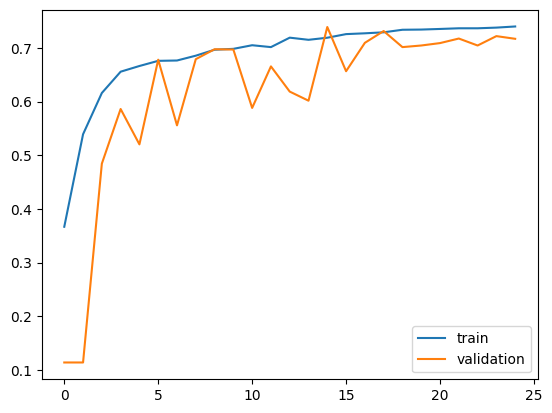

In [10]:
plt.plot(model_prediction.history['accuracy'], label='train')
plt.plot(model_prediction.history['val_accuracy'], label='validation')
plt.legend()
plt.show()